# ЛР № 01. Основы языковых моделей

**Вариант:** студенческий  
**Учебный профиль:** Greenfield Town  
**Время:** 6 академических часов  
**Seed:** 42

Перед работой выберите один из равноправных маршрутов: [компактную лекцию](lecture_01_language_model_basics_compact.md) с доступным первым объяснением или [полный лонгрид](lecture_01_language_model_basics.md) с подробными разборами. Затем работайте с ячейками по порядку. Этот notebook оставляет рядом с кодом только то пояснение, которое нужно для очередного шага. После каждой части сформулируйте короткий вывод в Markdown-ячейке.

**Навигация:** [страница ЛР](README.md) · [компактная лекция](lecture_01_language_model_basics_compact.md) · [полный лонгрид](lecture_01_language_model_basics.md) · [Harbor example](lab_01_example.ipynb) · [student](lab_02_student.ipynb) · [teacher](lab_01_teacher.ipynb)


## Подготовка

Этот notebook читает единый активный профиль `Greenfield Town` из `data/greenfield_town.json` и не использует сеть.


In [2]:
from __future__ import annotations

from collections import Counter, defaultdict
from copy import deepcopy
import json
import math
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

from pathlib import Path

possible_lab_dirs = [Path.cwd(), Path.cwd() / "01-lab-language-model-basics"]
LAB_DIR = next((path for path in possible_lab_dirs if (path / "data" / "greenfield_town.json").is_file()), None)
if LAB_DIR is None:
    raise FileNotFoundError("Запустите notebook из корня проекта или каталога лабораторной работы.")

SCENARIO_PATH = LAB_DIR / "data" / "greenfield_town.json"
SCENARIO = json.loads(SCENARIO_PATH.read_text(encoding="utf-8"))
print(f"Активный профиль данных: {SCENARIO['title']}")


Активный профиль данных: Greenfield Town


## Как проходить этот notebook

**Профиль:** Greenfield Town. В student-варианте из кодовых ячеек самостоятельно дописывайте только ячейки с `TODO`; отдельные Markdown-ячейки ниже нужны для ваших письменных выводов.

1. Выполняйте §§1–6 строго сверху вниз: функции §1 нужны дальше, §2 использует BoW, §5 готовит PPL для §6.
2. Следующая ячейка после реализации — готовая контрольная проверка: запускайте её, но не переписывайте. Если она остановилась, исправьте текущую реализацию, а не переходите к следующему разделу.
3. §§1–2 образуют одну ветвь классификации документов. Skip-gram (§3), BPE (§4) и Count LM (§5) — самостоятельные учебные эксперименты, а не один конвейер; §6 оценивает их результаты разными способами.
4. Точные значения loss и ближайших слов могут немного отличаться между средами. Надёжные признаки готовности — форма тензора, диапазон числа, контрольное утверждение и объяснение ограничения метода.
5. После раздела заполните отдельную Markdown-ячейку ответа: назовите наблюдаемый вывод, причину и границу интерпретации.

Для теории можно выбрать [компактную лекцию](lecture_01_language_model_basics_compact.md) или [полный лонгрид](lecture_01_language_model_basics.md): это равноправные маршруты разной глубины.


## 1. Мешок слов и n-граммы

Для объяснения выберите §1 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). В этом шаге нужно превратить строку в список токенов, назначить каждому токену устойчивый индекс и построить бинарный вектор. BoW хранит присутствие токена, но не его позицию; n-граммы ниже покажут, какую часть порядка можно вернуть.


### Маршрут §1: от строки к признакам

**Зачем.** Следующие разделы не умеют читать строку напрямую: им нужны устойчивые номера слов и бинарные признаки документа.

**Где писать.** В следующей ячейке с четырьмя незавершёнными функциями.

**Порядок.** 1) привести текст к нижнему регистру и выделить английские слова; 2) собрать уникальные токены всех документов и отсортировать их; 3) создать нулевой вектор длины словаря и поставить единицы только известным словам документа; 4) пройти по списку токенов скользящими окнами длины `n`.

**Не меняйте.** Данные профиля, порядок классов и контрольную ячейку после реализации.

**Что запустить.** Сразу следующую ячейку с DTM и тепловой картой.

**Готово, если.** В Greenfield Town напечатаны словарь из 51 токенов и DTM `12 × 51`; BoW двух переставленных фраз совпадают, но их биграммы различаются.

**Если не получилось.** Проверьте, что BoW бинарный: повтор слова не создаёт `2`, а OOV-слово не получает новый индекс. Если DTM имеет другую ширину, словарь должен строиться один раз по всем документам.

**Что записать.** Наблюдение о разреженности, причина потери порядка и роль биграмм.


In [3]:
def tokenize(text: str) -> list[str]:
    """Верните список строчных английских слов без пунктуации."""
    return re.findall(r"[a-z]+", text.lower())


def build_vocabulary(texts: list[str]) -> dict[str, int]:
    """Верните словарь «токен -> индекс» с алфавитным порядком токенов."""
    unique_tokens = set()
    for text in texts:
        unique_tokens.update(tokenize(text))
    return {token: index for index, token in enumerate(sorted(unique_tokens))}


def doc_to_bow(text: str, vocabulary: dict[str, int]) -> list[int]:
    """Верните бинарный BoW-вектор длины len(vocabulary)."""
    vector = [0] * len(vocabulary)
    for token in tokenize(text):
        if token in vocabulary:
            vector[vocabulary[token]] = 1
    return vector


def make_ngrams(tokens: list[str], n: int) -> list[tuple[str, ...]]:
    if len(tokens) < n:
        return []
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


Размер словаря: 51
Форма DTM: (12, 51); плотность: 0.113


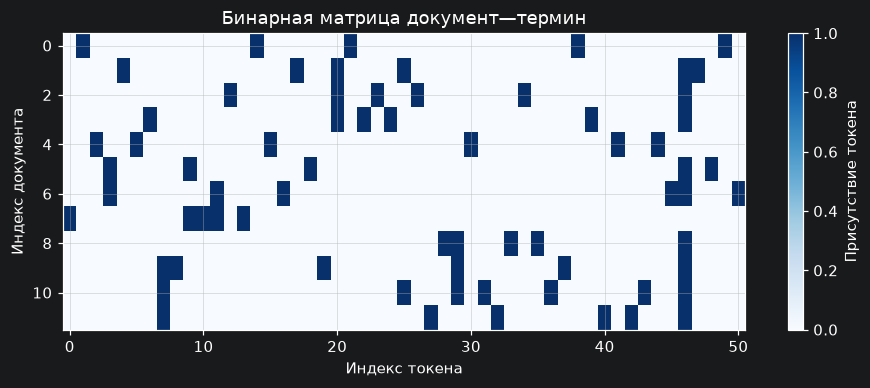

BoW совпадают: True
Биграммы первой фразы: [('garden', 'gate'), ('gate', 'opens')]
Биграммы второй фразы: [('opens', 'gate'), ('gate', 'garden')]


In [4]:
classification_data = SCENARIO["classification"]
CLASS_NAMES = classification_data["class_names"]
DOCS = [record["text"] for record in classification_data["documents"]]
class_to_id = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
LABELS = torch.tensor(
    [class_to_id[record["label"]] for record in classification_data["documents"]],
    dtype=torch.long,
)

vocabulary = build_vocabulary(DOCS)
document_vectors = torch.tensor([doc_to_bow(doc, vocabulary) for doc in DOCS], dtype=torch.float32)
density = float(document_vectors.mean())
print(f"Размер словаря: {len(vocabulary)}")
print(f"Форма DTM: {tuple(document_vectors.shape)}; плотность: {density:.3f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
dtm_image = ax.imshow(document_vectors.numpy(), aspect="auto", cmap="Blues")
ax.set_xlabel("Индекс токена")
ax.set_ylabel("Индекс документа")
ax.set_title("Бинарная матрица документ—термин")
fig.colorbar(dtm_image, ax=ax, label="Присутствие токена")
plt.show()

first_text, second_text = classification_data["order_examples"]
first = tokenize(first_text)
second = tokenize(second_text)
order_vocabulary = build_vocabulary([first_text, second_text])
print("BoW совпадают:", doc_to_bow(first_text, order_vocabulary) == doc_to_bow(second_text, order_vocabulary))
print("Биграммы первой фразы:", make_ngrams(first, 2))
print("Биграммы второй фразы:", make_ngrams(second, 2))


**Вывод 1.** Почему DTM разрежена? Какой смысловой признак теряет BoW? Почему биграммы не являются универсальным решением?


### Ответ студента 1

- Наблюдение из вывода: словарь Greenfield Town содержит 51 токен, DTM имеет форму `(12, 51)` и плотность около 0.113; переставленные фразы `garden gate opens` и `opens gate garden` дают одинаковый бинарный BoW, но разные биграммы (`('garden','gate'),('gate','opens')` против `('opens','gate'),('gate','garden')`).
- Почему результат получился: документ активирует только несколько столбцов словаря из 51 (одно короткое предложение содержит 4-6 слов), поэтому большинство координат вектора остаются нулями — отсюда разрежённость. BoW ставит единицу за сам факт присутствия токена и не хранит его позицию, поэтому две строки с одинаковым набором слов, но разным порядком, дают один и тот же вектор.
- Ограничение метода: BoW не различает порядок слов и не умеет отличить «сад открывает ворота» от «ворота открывают сад»; биграммы возвращают порядок только локально (окно из двух соседних слов) и не подаются в классификатор — они отдельная демонстрация, а не встроенный признак.
- Ответ на вопрос: DTM разрежена, потому что короткий документ покрывает лишь малую часть из 51 известного слова словаря. BoW теряет признак порядка слов. Биграммы возвращают набор соседних пар и действительно различают переставленные фразы, но не являются универсальным решением: они не заменяют классификатор, требуют собственного (более крупного) словаря пар и всё равно видят лишь окно из двух соседних токенов, а не всю структуру предложения.


## 2. Softmax, кросс-энтропия и классификатор

Для объяснения выберите §2 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Контрольная ячейка показывает, как логиты превращаются в вероятности; затем ваша модель должна вернуть именно логиты. Убедитесь, что входные признаки имеют тип `float32`, метки — `torch.long`, а `Softmax` не добавлен в `forward`.


![Схема выходного слоя](assets/output_layer.png)

*Рисунок 1. Элементы выходного слоя формируют логиты для классов.*


### Маршрут §2.1: сначала ручная математика, затем проверка

**Зачем.** Softmax превращает три сравнительных логита в три вероятностные оценки, а кросс-энтропия показывает, насколько мало вероятности получила правильная метка.

**Где записать ответ.** В следующей Markdown-ячейке «Ответ студента 2.1», до запуска контрольного кода.

**Порядок.** Для логитов `(2.0, 1.0, 0.5)` отдельно найдите `exp(2.0)`, `exp(1.0)`, `exp(0.5)`; сложите их; разделите каждую экспоненту на сумму; для первого правильного класса возьмите `-log(p_0)`.

**Не меняйте.** Контрольную ячейку, её логиты и индекс правильного класса: она нужна для сравнения ручного результата с `torch.softmax` и `CrossEntropyLoss`.

**Готово, если.** Вероятности приблизительно равны `(0.629, 0.231, 0.140)`, их сумма равна `1`, а потеря около `0.464`.

**Если не получилось.** Проверьте, что делите каждую экспоненту на общую сумму трёх экспонент, а логарифм берёте от вероятности первого класса, а не от логита `2.0`.

**Что записать.** Три экспоненты, их сумму, три вероятности и `-log(p_0)` — в шаблон ответа непосредственно ниже.


### Шаг 2.1. Ручная проверка softmax и кросс-энтропии

До запуска контрольной ячейки вручную вычислите softmax для логитов `(2.0, 1.0, 0.5)`: сначала найдите три экспоненты, затем их сумму и три вероятности. Проверьте, что вероятности дают единицу. Если верен первый класс, вычислите `-log(p_0)` и кратко объясните, почему это кросс-энтропия. После этого запустите ячейку и сравните ручной результат с `torch.softmax` и `nn.CrossEntropyLoss`.


### Ответ студента 2.1

- `exp(2.0)`, `exp(1.0)`, `exp(0.5)`: 7.389, 2.718, 1.649
- Их сумма: 11.756
- Softmax с точностью до трёх знаков: (0.629, 0.231, 0.140)
- `-log(p_0)`: -log(0.629) ≈ 0.464
- Почему это совпадает с кросс-энтропией первого правильного класса: кросс-энтропия для одного документа определена как `L = -log(p_y)`, где `p_y` — вероятность именно верного класса после softmax. Если верный класс — Garden (индекс 0), то `L = -log(p_0) ≈ 0.464`. Это в точности то число, что печатает `torch_loss` через `nn.CrossEntropyLoss()`, потому что она сама делает softmax-нормировку логитов внутри и берёт отрицательный логарифм вероятности правильного класса.


Softmax: [0.6285 0.2312 0.1402]
Сумма вероятностей: 1.000000
Потеря вручную: 0.464369; PyTorch: 0.464369
Softmax не меняется после общего сдвига логитов: True


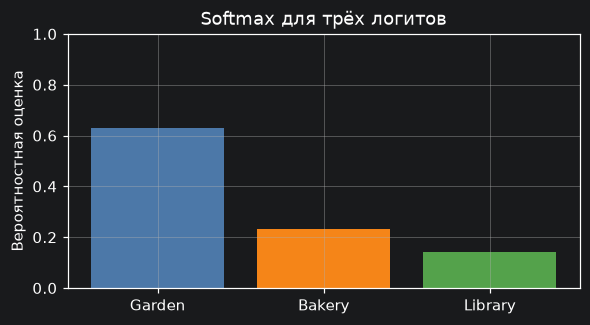

In [5]:
logits_example = torch.tensor([2.0, 1.0, 0.5])
probabilities_example = torch.softmax(logits_example, dim=0)
manual_loss = -math.log(float(probabilities_example[0]))
torch_loss = nn.CrossEntropyLoss()(logits_example.unsqueeze(0), torch.tensor([0]))
shifted_probabilities = torch.softmax(logits_example + 10.0, dim=0)
print("Softmax:", probabilities_example.numpy().round(4))
print(f"Сумма вероятностей: {probabilities_example.sum():.6f}")
print(f"Потеря вручную: {manual_loss:.6f}; PyTorch: {torch_loss.item():.6f}")
print("Softmax не меняется после общего сдвига логитов:", torch.allclose(probabilities_example, shifted_probabilities))
assert torch.isclose(probabilities_example.sum(), torch.tensor(1.0))
assert math.isclose(manual_loss, torch_loss.item(), rel_tol=1e-6)
assert torch.allclose(probabilities_example, shifted_probabilities)

plt.figure(figsize=(6, 3))
plt.bar(CLASS_NAMES, probabilities_example.numpy(), color=["#4c78a8", "#f58518", "#54a24b"])
plt.ylim(0, 1)
plt.ylabel("Вероятностная оценка")
plt.title("Softmax для трёх логитов")
plt.show()


### Шаг 2.2. Обучение и чтение результата классификатора

Реализуйте `SimpleClassifier`: первый `Linear` должен переводить `input_dim` в `hidden_dim`, `ReLU` не меняет форму, а второй `Linear` переводит `hidden_dim` в число классов. В `forward` верните логиты без `Softmax`. Затем запустите ячейку обучения и запишите начальную и финальную потерю, форму `new_document_logits` и объяснение: `argmax(dim=1)` выбирает класс отдельно для каждого документа.


### Маршрут §2.2: собрать и проверить классификатор

**Зачем.** Классификатор должен по одной BoW-строке выбрать один из классов `Garden`, `Bakery`, `Library`.

**Где писать.** В следующей ячейке класса `SimpleClassifier`; цикл обучения ниже уже готов и его менять не нужно.

**Порядок.** В конструкторе создайте первый линейный слой от длины BoW к 24 скрытым признакам, ReLU и второй линейный слой к трём классам. В `forward` примените их слева направо и верните необработанные логиты.

**Не меняйте.** Не добавляйте Softmax в `forward`, не меняйте `torch.long` у меток и не переписывайте готовые 800 шагов обучения.

**Что запустить.** Следующую ячейку обучения и чтения новых документов.

**Готово, если.** Поток имеет форму `(12, 51) → (12, 24) → (12, 3)`, loss уменьшается, а `new_document_logits` имеет форму `(2, 3)`.

**Если не получилось.** Ошибка форм обычно означает, что `input_dim` не равен длине BoW. Ошибка типа метки означает, что `LABELS` должны иметь тип `torch.long`. `argmax(dim=1)` выбирает класс внутри каждой строки, а не между документами.

**Что записать.** Начальную и финальную loss, форму логитов, смысл `dim=1` и ограничение: уменьшение train loss не доказывает обобщение.


In [6]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        hidden = self.relu(self.fc1(x))
        return self.fc2(hidden)


Форма classifier_model.fc1.weight: (24, 51)
Потеря: 1.0895 -> 0.0056
Формы потока: (12, 51) -> (12, 24) -> (12, 3)
Форма логитов: (2, 3)
fresh bread and cakes -> Bakery
readers visit the quiet library -> Library


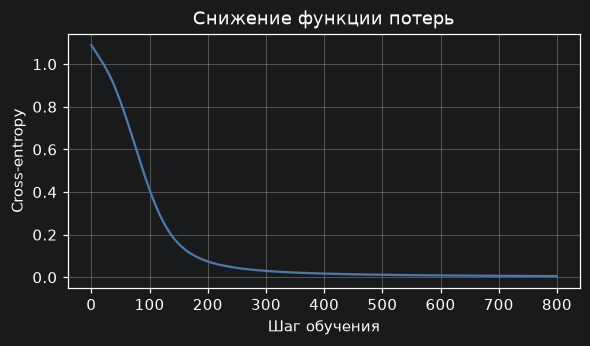

In [7]:
torch.manual_seed(SEED)
classifier_model = SimpleClassifier(input_dim=len(vocabulary), hidden_dim=24, output_dim=len(CLASS_NAMES))
print("Форма classifier_model.fc1.weight:", tuple(classifier_model.fc1.weight.shape))
assert tuple(classifier_model.fc1.weight.shape) == (24, len(vocabulary))
criterion = nn.CrossEntropyLoss()
classifier_optimizer = torch.optim.SGD(classifier_model.parameters(), lr=0.05)
classifier_losses = []
classifier_model.train()
for _ in range(800):
    classifier_optimizer.zero_grad()
    logits = classifier_model(document_vectors)
    classifier_loss = criterion(logits, LABELS)
    classifier_loss.backward()
    classifier_optimizer.step()
    classifier_losses.append(float(classifier_loss.detach()))

classifier_model.eval()
NEW_DOCS = classification_data["new_documents"]
new_document_vectors = torch.tensor([doc_to_bow(doc, vocabulary) for doc in NEW_DOCS], dtype=torch.float32)
with torch.no_grad():
    hidden_vectors = classifier_model.relu(classifier_model.fc1(document_vectors))
    new_document_logits = classifier_model(new_document_vectors)
    predicted_ids = torch.argmax(new_document_logits, dim=1)
print(f"Потеря: {classifier_losses[0]:.4f} -> {classifier_losses[-1]:.4f}")
print("Формы потока:", tuple(document_vectors.shape), "->", tuple(hidden_vectors.shape), "->", (len(DOCS), len(CLASS_NAMES)))
print("Форма логитов:", tuple(new_document_logits.shape))
assert tuple(hidden_vectors.shape) == (len(DOCS), 24)
assert tuple(new_document_logits.shape) == (len(NEW_DOCS), len(CLASS_NAMES))
for document, class_id in zip(NEW_DOCS, predicted_ids.tolist()):
    print(f"{document} -> {CLASS_NAMES[class_id]}")

plt.figure(figsize=(6, 3))
plt.plot(classifier_losses, color="#4c78a8")
plt.xlabel("Шаг обучения")
plt.ylabel("Cross-entropy")
plt.title("Снижение функции потерь")
plt.show()


**Вывод 2.** Почему в `forward` не нужен отдельный `Softmax`? Укажите форму `new_document_logits` и объясните роль `dim=1` в `argmax`.


### Ответ студента 2

- Наблюдение из вывода: loss упала с 1.0895 до 0.0056 за 800 full-batch шагов; поток форм — `(12, 51) → (12, 24) → (12, 3)`; форма логитов для двух новых документов — `(2, 3)`; оба новых документа классифицированы верно (`fresh bread and cakes -> Bakery`, `readers visit the quiet library -> Library`).
- Почему результат получился: 800 шагов SGD с lr=0.05 последовательно уменьшают cross-entropy на всех 12 обучающих документах, потому что слова bread/cakes/bakery и readers/library/books почти не пересекаются между классами и модель быстро находит веса, которые разделяют их по BoW-признакам.
- Ограничение метода: падение train loss показывает только то, что модель подстроилась под эти же 12 примеров; это не доказывает обобщение на незнакомые слова или темы — отдельного тестового набора здесь нет.
- Ответ на вопрос: Softmax не нужен в `forward`, потому что `nn.CrossEntropyLoss` сама выполняет численно устойчивую softmax-нормировку внутри и ожидает на входе сырые логиты — повторный softmax испортил бы масштаб и сделал обучение некорректным. `new_document_logits` имеет форму `(2, 3)`: 2 новых документа, 3 логита (по одному на класс) на каждый. `argmax(dim=1)` берёт максимум вдоль оси столбцов (классов) отдельно для каждой строки (документа) — то есть выбирает один лучший класс внутри каждой строки, а не один «лучший» документ среди всех.


## 3. Skip-gram и эмбеддинги

Для объяснения выберите §3 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Сначала создайте направленные пары «центр — контекст», затем передайте индексы центральных слов в `nn.Embedding` и предскажите индекс контекста. Слой хранит плотный вектор для каждого токена; это статическое представление, поэтому разные значения одного слова не разделяются.


![Схема skip-gram](assets/skip_gram.png)

*Рисунок 2. Центральный токен отображается в плотный вектор, из которого предсказывается контекст.*


### Маршрут §3: от соседей слова к эмбеддингам

**Зачем.** Skip-gram учит плотный вектор слова по его соседям, поэтому можно сравнить локальные окружения, а не только совпадение букв.

**Где писать.** В следующей ячейке: сначала функция пар, затем класс `SkipGramModel`, затем `nearest_words`.

**Порядок.** 1) для каждого центрального токена перечислите все токены окна радиуса 2, кроме него самого; 2) создайте слой `nn.Embedding` и линейный выход к размеру словаря; 3) в `forward` получите embedding центра и логиты контекста; 4) нормируйте все строки векторов, вычислите косинусные оценки и исключите само слово-запрос.

**Не меняйте.** Корпус, seed, готовый цикл обучения и число ближайших соседей.

**Что запустить.** Следующую ячейку, которая создаёт индексы, обучает модель и рисует двумерную проекцию.

**Готово, если.** Получено 196 направленных пар; поток имеет вид `center_ids (196,) → embedding (196, 12) → logits (196, 33)`; для `gardener` выведены три соседа, но само слово не попало в этот список.

**Если не получилось.** Самопара означает, что не исключен индекс центра. Ошибка размера выходного слоя означает, что он должен иметь столько выходов, сколько токенов в `embedding_vocabulary`. Положение точек на PCA-графике не является буквальной картой значений слов.

**Что записать.** Один наблюдаемый сосед, общий локальный контекст и ограничение малого корпуса.


In [8]:
def make_skipgram_pairs(tokens: list[str], window_size: int) -> list[tuple[str, str]]:
    pairs = []
    for center_index, center_token in enumerate(tokens):
        start = max(0, center_index - window_size)
        end = min(len(tokens), center_index + window_size + 1)
        for context_index in range(start, end):
            if context_index == center_index:
                continue
            pairs.append((center_token, tokens[context_index]))
    return pairs


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_ids: torch.Tensor) -> torch.Tensor:
        center_vectors = self.embedding(center_ids)
        return self.output(center_vectors)


def nearest_words(word: str, vocabulary: dict[str, int], vectors: torch.Tensor, top_k: int = 3):
    normalized = F.normalize(vectors, dim=1)
    query_index = vocabulary[word]
    scores = normalized @ normalized[query_index]
    inverse_vocabulary = {index: token for token, index in vocabulary.items()}
    ranked = sorted(
        ((inverse_vocabulary[index], float(score)) for index, score in enumerate(scores)),
        key=lambda item: item[1],
        reverse=True,
    )
    neighbors = [(token, score) for token, score in ranked if token != word]
    return neighbors[:top_k]


Токенов: 67; пар: 196; словарь: 33
Первые направленные пары: [('the', 'gardener'), ('the', 'waters'), ('gardener', 'the'), ('gardener', 'waters'), ('gardener', 'the'), ('waters', 'the')]
Ближайшие слова к 'gardener': [('garden', 0.573), ('baker', 0.464), ('gate', 0.459)]
Ближайшие слова к 'librarian': [('library', 0.655), ('bakery', 0.59), ('baker', 0.533)]


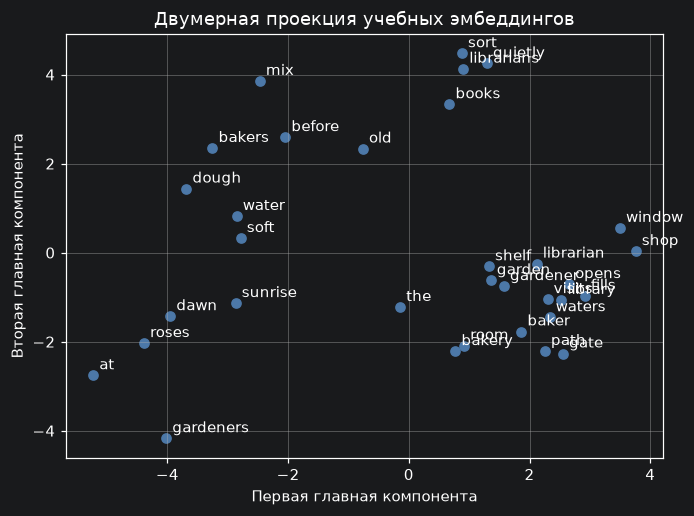

In [9]:
embedding_data = SCENARIO["embedding"]
embedding_lines = embedding_data["lines"]
embedding_tokens = [token for line in embedding_lines for token in tokenize(line)]
embedding_vocabulary = build_vocabulary(embedding_lines)
skipgram_pairs = [
    pair
    for line in embedding_lines
    for pair in make_skipgram_pairs(tokenize(line), window_size=embedding_data["window_size"])
]
center_ids = torch.tensor([embedding_vocabulary[center] for center, _ in skipgram_pairs], dtype=torch.long)
context_ids = torch.tensor([embedding_vocabulary[context] for _, context in skipgram_pairs], dtype=torch.long)
print(f"Токенов: {len(embedding_tokens)}; пар: {len(skipgram_pairs)}; словарь: {len(embedding_vocabulary)}")
print("Первые направленные пары:", skipgram_pairs[:6])
assert all(center != context for center, context in skipgram_pairs)

torch.manual_seed(SEED)
skipgram_model = SkipGramModel(len(embedding_vocabulary), embedding_dim=embedding_data["embedding_dim"])
skipgram_optimizer = torch.optim.Adam(skipgram_model.parameters(), lr=embedding_data["learning_rate"])
skipgram_model.train()
for _ in range(embedding_data["steps"]):
    skipgram_optimizer.zero_grad()
    skipgram_loss = nn.CrossEntropyLoss()(skipgram_model(center_ids), context_ids)
    skipgram_loss.backward()
    skipgram_optimizer.step()

skipgram_model.eval()
embeddings = skipgram_model.embedding.weight.detach()
for query_word in embedding_data["query_words"]:
    print(f"Ближайшие слова к {query_word!r}:", [(word, round(score, 3)) for word, score in nearest_words(query_word, embedding_vocabulary, embeddings)])

matrix = embeddings.numpy()
centered = matrix - matrix.mean(axis=0, keepdims=True)
_, _, right_vectors = np.linalg.svd(centered, full_matrices=False)
coordinates = centered @ right_vectors[:2].T
inverse_embedding_vocabulary = {index: token for token, index in embedding_vocabulary.items()}
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coordinates[:, 0], coordinates[:, 1], color="#4c78a8")
for index, point in enumerate(coordinates):
    ax.annotate(inverse_embedding_vocabulary[index], point, xytext=(4, 4), textcoords="offset points")
ax.set_title("Двумерная проекция учебных эмбеддингов")
ax.set_xlabel("Первая главная компонента")
ax.set_ylabel("Вторая главная компонента")
plt.show()


![Пространство эмбеддингов](assets/embedding_space.png)

*Рисунок 3. Двумерная проекция помогает сравнивать направления и расстояния между векторами.*


        **Вывод 3.** Назовите один наблюдаемый близкий вектор и объясните, почему малый учебный корпус не позволяет делать общие выводы о значениях слов.


### Ответ студента 3

- Наблюдение из вывода: подготовлено 67 токенов и 196 направленных пар при окне 2, словарь эмбеддингов — 33 токена. После обучения ближайшие соседи `gardener` — `garden` (0.573), `baker` (0.464), `gate` (0.459); ближайшие соседи `librarian` — `library` (0.655), `bakery` (0.59), `baker` (0.533). Само слово-запрос ни разу не попало в свой же список соседей.
- Почему результат получился: `gardener`, `baker` и `librarian` в учебных предложениях Greenfield часто стоят рядом с одинаковыми служебными словами (`the`, `opens`, `visits`, `fills`, названия мест), поэтому skip-gram, предсказывающий контекст по центральному слову, подтягивает их эмбеддинги в похожие направления — это чисто статистическое совпадение локальных контекстов, а не понимание профессии.
- Ограничение метода: корпус — всего 12 коротких предложений с окном радиуса 2; такой малый объём данных не позволяет делать общие выводы о значении слов — другой корпус, другой радиус окна или другая инициализация дадут другие числа соседства, а два слова с одинаковым смыслом, но без общих соседей в этих 12 строках, могут вообще не оказаться рядом.
- Ответ на вопрос: наблюдаемый сосед — `garden` для `gardener` (cos ≈ 0.573); их контексты похожи, потому что оба слова встречаются рядом с одинаковыми глаголами действия и служебными словами о саде. Этого недостаточно для общего вывода, так как корпус крошечный, окно фиксировано (2 токена), а близость отражает только совместную встречаемость в этих 12 предложениях, а не смысловую синонимию в языке в целом.


## 4. Подсловная токенизация BPE

Для объяснения выберите §4 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Эта символьная учебная BPE начинает с символов, считает соседние пары и последовательно сливает самые частые. Сохраняйте различие между частотой слова, частотой пары и упорядоченным списком `merges`; префикс `_` отмечает начало слова, а неизвестный символ заменяется на `<UNK>`.


### Маршрут §4: обучить и применить BPE

**Зачем.** Символьный BPE помогает представить новую словоформу как известные части, когда цельного слова нет в словаре.

**Где писать.** В следующей ячейке с пятью BPE-функциями — реализуйте их сверху вниз.

**Порядок.** 1) сохраните каждую словоформу как символы с `_` в начале и её частоту; 2) посчитайте соседние пары с весом частоты словоформы; 3) замените только точные соседние токены выбранной пары; 4) повторяйте подсчёт и слияние до лимита словаря; 5) при применении добавьте `_`, замените неизвестный символ на `<UNK>` и исполните `merges` по порядку.

**Не меняйте.** Лимит `50`, порядок уже выученных `merges` и контрольную ячейку.

**Что запустить.** Следующую ячейку, которая печатает первые правила и сегментации.

**Готово, если.** Число BPE-токенов не больше 50; слово `garden7` содержит `<UNK>` в результате сегментации.

**Если не получилось.** `_` обозначает начало слова. `<UNK>` — неизвестный символ BPE; `<unk>` строчными буквами появится только в Count LM как неизвестная цель. Если правила дают другой результат, проверьте, что они применяются в исходном порядке.

**Что записать.** Почему частота целой словоформы влияет на пару, что показывает `<UNK>` и почему порядок правил важен.


In [10]:
def initialize_vocabulary(corpus: list[str]):
    vocabulary: dict[str, int] = {}
    charset: set[str] = set()
    for word in corpus:
        segmented = " ".join(["_"] + list(word))
        vocabulary[segmented] = vocabulary.get(segmented, 0) + 1
        charset.add("_")
        charset.update(word)
    return vocabulary, charset


def get_pair_counts(vocabulary: dict[str, int]):
    pair_counts: Counter[tuple[str, str]] = Counter()
    for segmented, freq in vocabulary.items():
        symbols = segmented.split(" ")
        for left, right in zip(symbols, symbols[1:]):
            pair_counts[(left, right)] += freq
    return pair_counts


def merge_pair(vocabulary: dict[str, int], pair: tuple[str, str]):
    merged_token = "".join(pair)
    pattern = re.compile(r"(?<!\S)" + re.escape(pair[0]) + " " + re.escape(pair[1]) + r"(?!\S)")
    new_vocabulary: dict[str, int] = {}
    for segmented, freq in vocabulary.items():
        new_segmented = pattern.sub(merged_token, segmented)
        new_vocabulary[new_segmented] = new_vocabulary.get(new_segmented, 0) + freq
    return new_vocabulary


def byte_pair_encoding(corpus: list[str], vocab_size: int):
    vocabulary, charset = initialize_vocabulary(corpus)
    bpe_tokens = set(charset)
    merges: list[tuple[str, str]] = []
    while len(bpe_tokens) < vocab_size:
        pair_counts = get_pair_counts(vocabulary)
        if not pair_counts:
            break
        best_pair = max(pair_counts.items(), key=lambda item: item[1])[0]
        vocabulary = merge_pair(vocabulary, best_pair)
        merges.append(best_pair)
        bpe_tokens.add("".join(best_pair))
    return vocabulary, merges, charset, bpe_tokens


def tokenize_word(word: str, merges: list[tuple[str, str]], charset: set[str], unk_token: str = "<UNK>"):
    symbols = ["_"] + [char if char in charset else unk_token for char in word]
    for left, right in merges:
        merged_token = left + right
        new_symbols = []
        index = 0
        while index < len(symbols):
            if index < len(symbols) - 1 and symbols[index] == left and symbols[index + 1] == right:
                new_symbols.append(merged_token)
                index += 2
            else:
                new_symbols.append(symbols[index])
                index += 1
        symbols = new_symbols
    return symbols


In [11]:
bpe_data = SCENARIO["bpe"]
bpe_corpus = [token for text in bpe_data["corpus"] for token in tokenize(text)]
bpe_vocabulary, merges, charset, bpe_tokens = byte_pair_encoding(bpe_corpus, bpe_data["vocab_size"])
print(f"Размер начального алфавита: {len(charset)}")
print(f"Размер словаря BPE: {len(bpe_tokens)}; число слияний: {len(merges)}")
print("Шаг | сливаемая пара")
for step, pair in enumerate(merges[:10], start=1):
    print(f"{step:3d} | {pair[0]!r} + {pair[1]!r}")
for word in bpe_data["probe_words"]:
    print(f"{word:18s} -> {tokenize_word(word, merges, charset)}")
assert len(bpe_tokens) <= bpe_data["vocab_size"]
assert "<UNK>" in tokenize_word(bpe_data["probe_words"][-1], merges, charset)


Размер начального алфавита: 17
Размер словаря BPE: 50; число слияний: 33
Шаг | сливаемая пара
  1 | '_' + 'g'
  2 | '_g' + 'a'
  3 | 'd' + 'e'
  4 | '_ga' + 'r'
  5 | '_gar' + 'de'
  6 | '_garde' + 'n'
  7 | 'e' + 'r'
  8 | '_' + 'b'
  9 | '_garden' + 'er'
 10 | 'e' + 's'
garden             -> ['_garden']
garden7            -> ['_garden', '<UNK>']


**Вывод 4.** Почему частота пары должна учитывать частоту всего слова? Как `<UNK>` влияет на токенизацию тестового слова с неизвестным символом? Почему порядок `merges` нельзя произвольно менять?


### Ответ студента 4

- Наблюдение из вывода: начальный алфавит содержит 17 символов, итоговый словарь BPE — 50 токенов (лимит достигнут) за 33 слияния; первые правила — `('_','g') → '_g'`, `('_g','a') → '_ga'`, `('d','e') → 'de'` и т.д. Слово `garden` сегментируется как `['_garden']` (целиком выученный токен), а `garden7` — как `['_garden', '<UNK>']`, потому что цифра `7` не входит в charset.
- Почему результат получился: `garden`, `gardener`, `gardens` многократно встречаются в BPE-корпусе, поэтому пара символов `_g`, затем `_ga`, `_gar` и так далее оказывается самой частой на каждом шаге и последовательно сливается в единый токен `_garden`; цифра `7` никогда не входила в исходный символьный алфавит корпуса, поэтому при применении правил к `garden7` она заменяется на `<UNK>` ещё до попытки слияния.
- Ограничение метода: `<UNK>` в BPE означает неизвестный *символ*, а не неизвестное *слово* — это не имеет отношения к `<unk>` в счётной языковой модели из §5; красивый выученный подслов вроде `_garden` не означает, что модель «поняла» значение сада — она лишь нашла частую последовательность символов в конкретном корпусе.
- Ответ на вопрос: частота пары должна учитывать частоту всей словоформы, потому что повторившееся слово сильнее влияет на выбор частой пары, чем слово, встретившееся один раз (функция `get_pair_counts` взвешивает пары на `freq(w)`). `<UNK>` в токенизации `garden7` показывает, что символ `7` отсутствовал в обучающем алфавите — модель честно сигнализирует о неизвестном символе, а не молча его пропускает. Порядок `merges` нельзя менять, потому что каждое следующее правило рассчитывает найти токены, созданные предыдущими слияниями (например, `('_g','a')` не сработает, пока не применено `('_','g')`); при другом порядке сегментация слова стала бы другой и невоспроизводимой.


## 5. Счётная триграммная языковая модель

Для объяснения выберите §5 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Триграмма оценивает следующее слово по двум предыдущим. Реализуйте отдельно хранение частот, поиск самого длинного доступного контекста и сглаженную вероятность; не смешивайте общий смысл $P$, несглаженную оценку $P_{\mathrm{MLE}}$ и реализованную $P_{+1}$.


### Маршрут §5: посчитать продолжения и вероятность

**Зачем.** Count LM отвечает на вопрос: какое слово чаще всего продолжает левый контекст и с какой сглаженной вероятностью?

**Где писать.** В следующей ячейке: сначала конструктор, затем `train`, прогноз, вероятность, генерация и PPL.

**Порядок.** 1) создайте отдельные словари счётчиков для униграмм, биграмм и триграмм; 2) в `train` заполните их скользящими окнами; 3) для прогноза ищите контекст длины 2, затем 1, затем 0; 4) для жадного выбора используйте сырые частоты; 5) для `get_probability` и PPL примените add-one сглаживание; 6) при генерации добавляйте найденный токен к текущей истории.

**Не меняйте.** `n=3`, токены train/test и готовую проверочную ячейку.

**Что запустить.** Следующую ячейку с известным и незнакомым контекстом, нормировкой и жадным продолжением.

**Готово для §5, если.** Контекст `['the', 'garden']` продолжается словом `gate`; сумма сглаженных вероятностей равна 1, неизвестная цель имеет положительную вероятность. Конечную PPL проверьте первой ячейкой §6: она использует эти же вероятности на отдельной тестовой последовательности.

**Если не получилось.** Незнакомый контекст запускает backoff, а неизвестная цель заменяется на `<unk>`; это разные случаи. Не используйте сглаженные вероятности для `predict_next_token`: он читает самый частый токен из `Counter`.

**Что записать.** Порядок backoff, роль сглаживания для PPL и ограничение: триграмма видит не более двух предыдущих слов.


In [12]:
class CountLanguageModel:
    def __init__(self, n: int):
        self.n = n
        self.ngram_counts: list[dict[tuple[str, ...], Counter[str]]] = [defaultdict(Counter) for _ in range(n)]
        self.vocabulary: set[str] = set()

    def predict_next_token(self, context: list[str] | tuple[str, ...]):
        context = tuple(context)
        for order in range(self.n, 0, -1):
            context_key = context[-(order - 1):] if order > 1 else ()
            counts = self.ngram_counts[order - 1].get(context_key)
            if counts:
                return counts.most_common(1)[0][0]
        return None

    def get_probability(self, token: str, context: list[str] | tuple[str, ...]) -> float:
        context = tuple(context)
        target = token if token in self.vocabulary else "<unk>"
        vocabulary_size = len(self.vocabulary)
        for order in range(self.n, 0, -1):
            context_key = context[-(order - 1):] if order > 1 else ()
            counts = self.ngram_counts[order - 1].get(context_key)
            if counts:
                total = sum(counts.values())
                return (counts.get(target, 0) + 1) / (total + vocabulary_size)
        return 1.0 / vocabulary_size


def train(model: CountLanguageModel, tokens: list[str]) -> None:
    model.vocabulary = set(tokens) | {"<unk>"}
    for order in range(1, model.n + 1):
        context_length = order - 1
        for index in range(len(tokens) - order + 1):
            context = tuple(tokens[index:index + context_length])
            next_token = tokens[index + context_length]
            model.ngram_counts[order - 1][context][next_token] += 1


def generate_text(model: CountLanguageModel, context: list[str], num_tokens: int) -> str:
    history = list(context)
    generated = list(context)
    for _ in range(num_tokens):
        next_token = model.predict_next_token(tuple(history))
        if next_token is None:
            break
        generated.append(next_token)
        history.append(next_token)
    return " ".join(generated)


def compute_perplexity(model: CountLanguageModel, tokens: list[str], context_size: int) -> float:
    if not tokens:
        return float("inf")
    log_probabilities = []
    for index, token in enumerate(tokens):
        context = tuple(tokens[max(0, index - context_size):index])
        probability = model.get_probability(token, context)
        log_probabilities.append(math.log(probability))
    return math.exp(-sum(log_probabilities) / len(log_probabilities))


In [13]:
lm_data = SCENARIO["language_model"]
lm_train_tokens = tokenize(lm_data["train_text"])
lm_test_tokens = tokenize(lm_data["test_text"])

count_lm = CountLanguageModel(n=lm_data["n"])
train(count_lm, lm_train_tokens)
known_context = lm_data["known_context"]
unknown_context = lm_data["unknown_context"]
print("Знакомый контекст:", known_context, "->", count_lm.predict_next_token(known_context))
print("Незнакомый контекст:", unknown_context, "->", count_lm.predict_next_token(unknown_context))
print("P(unknown | unseen context) =", f"{count_lm.get_probability('unknown', unknown_context):.8f}")
probability_sum = sum(count_lm.get_probability(token, known_context) for token in count_lm.vocabulary)
print(f"Сумма P(token | знакомый контекст): {probability_sum:.12f}")
print("Продолжение:", generate_text(count_lm, lm_data["generation_context"], lm_data["generation_length"]))
assert count_lm.get_probability("unknown", unknown_context) > 0
assert math.isclose(probability_sum, 1.0, rel_tol=1e-12, abs_tol=1e-12)


Знакомый контекст: ['the', 'garden'] -> gate
Незнакомый контекст: ['silent', 'garden'] -> gate
P(unknown | unseen context) = 0.05555556
Сумма P(token | знакомый контекст): 1.000000000000
Продолжение: the garden gate opens at dawn the


**Вывод 5.** Опишите порядок отступа к более короткому контексту (backoff). Почему сглаживание Лапласа важно для перплексии? Назовите ограничение триграммной модели при работе с длинным текстом.


### Ответ студента 5

- Наблюдение из вывода: для знакомого контекста `['the', 'garden']` модель предсказывает `gate` с вероятностью `P=0.166667`; для незнакомого контекста `['silent', 'garden']` она тоже предсказывает `gate` — то есть сработал backoff к биграмме `('garden',)`, так как триграммы `('silent','garden')` не было в обучении. `P('unknown' | незнакомый контекст) = 0.05555556` — положительна благодаря `<unk>` и сглаживанию. Сумма сглаженных вероятностей по всему словарю для знакомого контекста равна `1.000000000000`. Жадная генерация от `['the','garden']` даёт `the garden gate opens at dawn the`. Перплексия на тестовой последовательности `the garden gate opens at dusk` — `5.63`.
- Почему результат получился: `predict_next_token` ищет самый длинный доступный контекст — сначала триграммный, затем биграммный, затем униграммный — и берёт самое частое сырое продолжение из соответствующего `Counter`; для `('silent','garden')` триграммного контекста не было, поэтому модель отступила («backoff») к биграмме `('garden',)`, где `gate` — самое частое продолжение в обучающем тексте. `get_probability` вместо этого всегда добавляет `+1` к каждому счётчику и `+|V|` в знаменатель (add-one сглаживание), поэтому даже никогда не виденное слово (`<unk>`) получает положительную, а не нулевую вероятность.
- Ограничение метода: триграмма хранит контекст длиной максимум два предыдущих токена — она не может связать слово с причиной, которая была дальше в начале длинного текста, и не объединяет похожие по смыслу слова (`garden` и `gardener` — разные ключи).
- Ответ на вопрос: backoff идёт по убыванию длины контекста — сначала два последних токена (триграмма), затем один последний токен (биграмма), затем пустой контекст (униграмма) — и останавливается на первом уровне, где для данного контекста есть наблюдения. Сглаживание Лапласа важно для перплексии, потому что `log(0)` не определён: без `+1` любое невиданное продолжение обнулило бы вероятность всей тестовой последовательности и сделало PPL неопределённой. Ограничение триграммы при работе с длинным текстом — она видит не более двух предыдущих слов и не умеет учитывать более дальний контекст предложения.


## 6. Перплексия, ROUGE и Elo

Для объяснения выберите §6 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Перплексия оценивает вероятность тестовых токенов, ROUGE — перекрытие с эталоном, а Elo — попарное предпочтение. Сначала назовите входы и диапазон каждой метрики: эти числа отвечают на разные вопросы и не заменяют друг друга.


In [14]:
perplexity = compute_perplexity(count_lm, lm_test_tokens, context_size=count_lm.n - 1)
print(f"Перплексия на тестовой последовательности: {perplexity:.2f}")
assert math.isfinite(perplexity)


Перплексия на тестовой последовательности: 5.63


### Маршрут §6: измерить разные стороны качества

**Зачем.** PPL, ROUGE, Лайкерт и Elo отвечают на разные вопросы; одной цифрой качество текста здесь не измеряется.

**Где писать.** В следующей ячейке с метриками; реализуйте функции в порядке их объявления.

**Порядок.** 1) токенизируйте кандидат и эталон, сформируйте `Counter` n-грамм; 2) для ROUGE-N сложите минимумы кратностей; 3) для LCS заполните таблицу динамического программирования; 4) соедините точность и полноту в ROUGE-L; 5) вычислите ожидаемый балл Elo; 6) обновите оба рейтинга из ожиданий до изменения пары.

**Не меняйте.** Эталон, кандидаты, журнал матчей, `beta=8` и начальные рейтинги 1500.

**Что запустить.** Следующую ячейку с функциями метрик, а затем готовые ячейки ROUGE и Elo. PPL уже напечатана непосредственно выше.

**Готово, если.** PPL конечна; все ROUGE лежат в `[0, 1]`, кандидаты A и B дают разные значения, а сумма трёх Elo-рейтингов остаётся `4500`.

**Если не получилось.** `generated` — кандидат, `reference` — эталон. Повторы нужно учитывать через `min`, а не через множество. При Elo рассчитайте `expected_left` и `expected_right` до изменения рейтинга первого участника.

**Что записать.** Почему overlap не доказывает истинность; какую сильную сторону и какое ограничение имеет PPL; зачем нужны люди и почему Elo требует многих сравнений.


In [15]:
def ngram_counter(text: str, n: int) -> Counter[tuple[str, ...]]:
    return Counter(make_ngrams(tokenize(text), n))


def rouge_n_recall(generated: str, reference: str, n: int) -> float:
    reference_counts = ngram_counter(reference, n)
    total_reference = sum(reference_counts.values())
    if total_reference == 0:
        return 0.0
    generated_counts = ngram_counter(generated, n)
    overlap = sum(min(count, generated_counts.get(gram, 0)) for gram, count in reference_counts.items())
    return overlap / total_reference


def lcs_length(left: list[str], right: list[str]) -> int:
    table = [[0] * (len(right) + 1) for _ in range(len(left) + 1)]
    for i in range(1, len(left) + 1):
        for j in range(1, len(right) + 1):
            if left[i - 1] == right[j - 1]:
                table[i][j] = table[i - 1][j - 1] + 1
            else:
                table[i][j] = max(table[i - 1][j], table[i][j - 1])
    return table[len(left)][len(right)]


def rouge_l(generated: str, reference: str, beta: float = 8.0) -> float:
    generated_tokens = tokenize(generated)
    reference_tokens = tokenize(reference)
    if not generated_tokens or not reference_tokens:
        return 0.0
    lcs = lcs_length(generated_tokens, reference_tokens)
    recall = lcs / len(reference_tokens)
    precision = lcs / len(generated_tokens)
    if recall == 0 and precision == 0:
        return 0.0
    beta_sq = beta ** 2
    return ((1 + beta_sq) * recall * precision) / (recall + beta_sq * precision)


def expected_score(rating_a: float, rating_b: float) -> float:
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / 400))


def update_elo(rating: float, actual_score: float, expected: float, k: float = 32) -> float:
    return rating + k * (actual_score - expected)


Модель | ROUGE-1 | ROUGE-2 | ROUGE-L
A      |   1.000 |   0.600 |   0.831
B      |   0.000 |   0.000 |   0.000


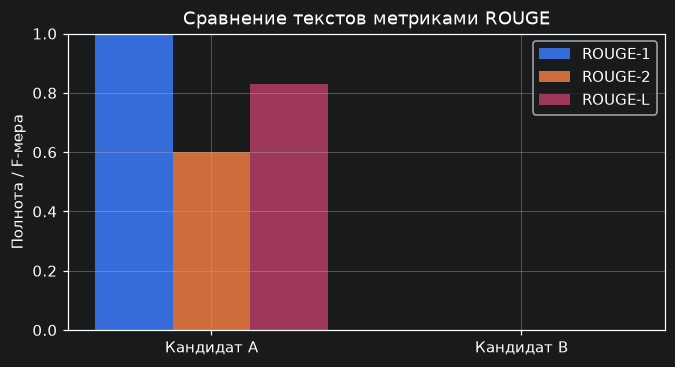

In [16]:
evaluation_data = SCENARIO["evaluation"]
reference = evaluation_data["reference"]
candidate_by_name = {item["name"]: item["text"] for item in evaluation_data["candidates"]}

rows = []
for name, candidate in candidate_by_name.items():
    rows.append((name, rouge_n_recall(candidate, reference, 1), rouge_n_recall(candidate, reference, 2), rouge_l(candidate, reference)))
print("Модель | ROUGE-1 | ROUGE-2 | ROUGE-L")
for name, r1, r2, rl in rows:
    print(f"{name:6s} | {r1:7.3f} | {r2:7.3f} | {rl:7.3f}")
assert all(0 <= value <= 1 for _, *values in rows for value in values)

names = [row[0] for row in rows]
x = np.arange(len(names))
plt.figure(figsize=(7, 3.5))
plt.bar(x - 0.25, [row[1] for row in rows], width=0.25, label="ROUGE-1")
plt.bar(x, [row[2] for row in rows], width=0.25, label="ROUGE-2")
plt.bar(x + 0.25, [row[3] for row in rows], width=0.25, label="ROUGE-L")
plt.xticks(x, ["Кандидат " + name for name in names])
plt.ylim(0, 1)
plt.ylabel("Полнота / F-мера")
plt.title("Сравнение текстов метриками ROUGE")
plt.legend()
plt.show()


In [17]:
matches = [(left, right, float(left_score)) for left, right, left_score in evaluation_data["elo_matches"]]
ratings = {name: 1500.0 for name in evaluation_data["elo_names"]}
for left, right, left_score in matches:
    expected_left = expected_score(ratings[left], ratings[right])
    expected_right = 1 - expected_left
    ratings[left] = update_elo(ratings[left], left_score, expected_left)
    ratings[right] = update_elo(ratings[right], 1 - left_score, expected_right)
print("Итоговые Elo:")
for name, rating in sorted(ratings.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {rating:.1f}")
assert math.isclose(sum(ratings.values()), 4500.0, rel_tol=1e-12)


Итоговые Elo:
Bakery-LM: 1501.5
Garden-LM: 1499.3
Library-LM: 1499.2


### Шкала Лайкерта для ручной оценки

Оцените каждый текст по трём независимым критериям: связность, информативность и фактологическая точность.

| Балл | Интерпретация |
| ---: | --- |
| -2 | Критерий практически не выполнен. |
| -1 | Критерий выполнен с существенными недостатками. |
| 0 | Результат приемлем, но без убедительных достоинств. |
| 1 | Критерий выполнен хорошо. |
| 2 | Критерий выполнен полностью и убедительно. |

**Вывод 6.** Почему высокий ROUGE не доказывает фактологическую точность? Почему Elo требует многих попарных сравнений? Какую сильную сторону и какое ограничение имеет перплексия?


### Ответ студента 6

- Наблюдение из вывода: PPL на тестовой последовательности конечна (5.63). Для эталона `the garden gate opens at dawn` кандидат A (`the gate opens at dawn near garden`) даёт ROUGE-1 = 1.000, ROUGE-2 = 0.600, ROUGE-L ≈ 0.831; кандидат B (`books rest in a quiet library`) даёт нули по всем трём метрикам. Сумма трёх рейтингов Elo после матчей осталась `4500.0` (Bakery-LM: 1501.5, Garden-LM: 1499.3, Library-LM: 1499.2).
- Почему результат получился: A содержит все шесть слов эталона (поэтому ROUGE-1 = 1.0), но `garden` переставлено и добавлено слово `near`, поэтому часть биграмм эталона не совпадает (ROUGE-2 = 0.6), а ROUGE-L учитывает наибольшую общую подпоследовательность и штрафует за лишнее слово через точность. B не пересекается с эталоном по лексике вообще, поэтому все ROUGE-значения нулевые. Elo-обновления симметричны (проигравший теряет ровно столько очков, сколько получает победитель), поэтому сумма рейтингов сохраняется по конструкции формулы, а не потому, что рейтинги отражают «истинную» силу моделей.
- Ограничение метода: ROUGE — метрика лексического перекрытия: она не проверяет, верен ли кандидат по смыслу или по фактам, а лишь считает совпавшие n-граммы. PPL измеряет только то, насколько модель «удивлена» истинными тестовыми токенами при teacher forcing — она ничего не говорит о красоте текста или о фактологической точности собственной жадной генерации. Elo сравнивает силу относительно конкретных соперников в конкретном порядке матчей и не даёт абсолютной оценки качества по одному сравнению.
- Ответ на вопрос: высокий ROUGE не доказывает фактологическую точность, потому что он считает только совпадение слов/n-грамм с эталоном — кандидат может повторить почти весь текст эталона и при этом изменить число, имя или отрицание, и ROUGE этого не заметит. Elo требует многих попарных сравнений, потому что один матч даёт лишь одно обновление ожидания-результата — устойчивый рейтинг появляется только после накопления статистики по разным соперникам и порядку встреч. Сильная сторона перплексии — она даёт объективное число, основанное на реальных вероятностях модели для истинного продолжения; её ограничение — она не измеряет смысл, стиль или фактическую верность и несравнима между разными словарями/токенизациями. Человеческая оценка (Лайкерт) добавляет то, чего не даёт ни одна автоматическая метрика — суждение о связности, информативности и фактологической точности, которое ROUGE и PPL напрямую не измеряют.

#### Ручная оценка Лайкерта кандидата A

Эти оценки не выводятся из ROUGE: для каждого критерия укажите собственное краткое обоснование по тексту кандидата.

| Критерий | Балл от -2 до 2 | Короткое обоснование |
| --- | ---: | --- |
| Связность | 1 | Предложение грамматически цельное и читается естественно, хотя перестановка `garden` в конец делает акцент немного странным. |
| Информативность | 1 | Сохранены все ключевые слова эталона (сад, ворота, открываются, рассвет), смысл передан почти полностью. |
| Фактологическая точность | 0 | Порядок событий/объектов изменён (`garden` перемещён, добавлено `near`), из-за чего буквальное описание сцены немного отличается от эталона, хотя ключевые факты не искажены. |


## Итоговый практический результат: мини-портфолио текстового эксперимента

До этого места вы реализовали шесть связанных тем, но это не один искусственный конвейер: BPE, skip-gram и счётная языковая модель решают разные учебные задачи. Ниже готовая базовая ячейка собирает четыре самостоятельных результата в один понятный отчёт. Она использует готовые объекты предыдущих частей и запускается после их выполнения.

| Раздел лекции | Реализованный компонент | Что показывает итоговый отчёт | Проверка и граница вывода | Как переносить на похожую задачу |
| --- | --- | --- | --- | --- |
| §1 | `tokenize`, бинарный BoW, n-граммы | Токены, известные и OOV-слова, активные признаки и биграммы документа | Нулевой BoW означает отсутствие известных признаков; порядок и частоты не становятся признаками классификатора | Заменить документы, затем заново построить словарь и DTM |
| §2 | `SimpleClassifier` | Логиты, вероятности и тематический класс документа | Форма `(1, 3)`, сумма вероятностей равна 1; это не доказательство качества на новых данных | Подать новые документы и метки, затем переобучить модель |
| §3 | skip-gram и `nearest_words` | Три ближайших по косинусному сходству слова | Запрос не должен попасть в собственный список; близость относится только к малому корпусу | Заменить корпус контекстов и обучить эмбеддинги заново |
| §4 | символьный BPE | Разбиение нового слова на подслова и `<UNK>` для неизвестного символа | `<UNK>` — неизвестный символ BPE, а не неизвестное слово LM | Заменить корпус или размер словаря и обучить новые `merges` |
| §5 | счётная триграммная LM | Жадное продолжение, вероятность следующего токена и PPL тестовой последовательности | Конечная PPL использует teacher forcing; триграмма видит не более двух предыдущих токенов | Заменить обучающую и тестовую последовательности, затем обучить LM заново |
| §6 | PPL, ROUGE, Лайкерт и Elo | PPL, три ROUGE-значения, итог Elo и ручная оценка в паспорте | ROUGE не проверяет истинность, Лайкерт субъективен, Elo требует многих сравнений | Заменить кандидата, эталон и журнал сравнений; интерпретировать метрики вместе |

Полный результат — не только напечатанные числа. После базовой ячейки заполните паспорт: зафиксируйте наблюдение, проверку, ограничение и следующий безопасный шаг адаптации.


### Как завершить мини-портфолио

**Зачем.** Это не новая модель и не новая задача: отчёт собирает четыре уже реализованных результата, чтобы у каждого были вход, вывод, проверка и ограничение.

**Ваше действие.** Не изменяйте `PORTFOLIO_CASE` и `run_portfolio_case`; запустите готовую ячейку только после успешных §§1–6.

**Готово, если.** Напечатаны девять строк `✓`: форма логитов, нормировка softmax, известные признаки, запрос эмбеддингов, исключение самого слова, `<UNK>` BPE, конечная PPL, диапазон ROUGE и сумма Elo `4500`.

**Что записать.** В паспорте заполните все четыре строки по конкретному выводу отчёта. Укажите вход, наблюдаемый результат, проверенный инвариант, ограничение и одно действие для переноса на похожую задачу.

**Песочница.** Только после базового отчёта разрешено менять значения `CUSTOM_CASE`. Она проверяет OOV и пустой текст, не влияет на базовый результат и не заменяет обязательный паспорт.


In [18]:
portfolio_data = SCENARIO["portfolio"]
PORTFOLIO_CASE = {
    **portfolio_data,
    "perplexity_tokens": lm_test_tokens,
    "candidate": candidate_by_name[portfolio_data["candidate_name"]],
    "reference": reference,
}


def as_tokens(value):
    '''Безопасно приводит строку или последовательность к учебным словным токенам.'''
    if isinstance(value, str):
        return tokenize(value)
    if isinstance(value, (list, tuple)):
        return [token for item in value for token in tokenize(str(item))]
    return []


def bounded_count(value, default=5):
    '''Не даёт необязательной песочнице случайно запросить слишком длинную генерацию.'''
    try:
        return min(max(int(value), 0), 20)
    except (TypeError, ValueError):
        return default


def run_portfolio_case(case, title, strict=False):
    '''Собирает отчёт, не меняя модель, словари, merges или исходные данные.'''
    document = str(case.get("document", ""))
    document_tokens = tokenize(document)
    known_tokens = sorted({token for token in document_tokens if token in vocabulary})
    oov_tokens = sorted({token for token in document_tokens if token not in vocabulary})
    document_bigrams = make_ngrams(document_tokens, 2)
    document_vector = torch.tensor([doc_to_bow(document, vocabulary)], dtype=torch.float32)

    if known_tokens:
        was_training = classifier_model.training
        classifier_model.eval()
        with torch.no_grad():
            document_logits = classifier_model(document_vector)
            document_probabilities = torch.softmax(document_logits, dim=1)
            document_class_id = int(torch.argmax(document_logits, dim=1).item())
        classifier_model.train(was_training)
        classification_message = "Класс выбран по известным бинарным признакам документа."
    else:
        document_logits = None
        document_probabilities = None
        document_class_id = None
        classification_message = "BoW нулевой: у модели нет лексического признака для содержательной классификации."

    query_tokens = as_tokens(case.get("embedding_word", ""))
    embedding_query = query_tokens[0] if len(query_tokens) == 1 else None
    if embedding_query in embedding_vocabulary:
        nearest = nearest_words(embedding_query, embedding_vocabulary, embeddings, top_k=3)
        embedding_message = "Запрос найден в словаре эмбеддингов."
    else:
        nearest = []
        embedding_message = "Запроса нет в словаре эмбеддингов: близкие слова не вычисляются."

    bpe_word = str(case.get("bpe_word", ""))
    if bpe_word:
        bpe_result = tokenize_word(bpe_word, merges, charset)
        bpe_message = "<UNK> здесь означает неизвестный символ, а не неизвестное слово языковой модели."
    else:
        bpe_result = []
        bpe_message = "Пустую строку сегментировать не нужно: в ней нет символов слова."

    lm_context = as_tokens(case.get("lm_context", []))
    num_tokens = bounded_count(case.get("num_tokens", 5))
    predicted_token = count_lm.predict_next_token(lm_context)
    predicted_probability = count_lm.get_probability(predicted_token, lm_context)
    generated_text = generate_text(count_lm, lm_context, num_tokens)
    ppl_tokens = as_tokens(case.get("perplexity_tokens", []))
    portfolio_ppl = compute_perplexity(count_lm, ppl_tokens, context_size=count_lm.n - 1)

    candidate = str(case.get("candidate", ""))
    portfolio_reference = str(case.get("reference", ""))
    rouge_scores = {
        "ROUGE-1": rouge_n_recall(candidate, portfolio_reference, 1),
        "ROUGE-2": rouge_n_recall(candidate, portfolio_reference, 2),
        "ROUGE-L": rouge_l(candidate, portfolio_reference),
    }
    elo_total = sum(ratings.values())
    elo_leader = max(ratings, key=ratings.get)

    report = {
        "classification": {
            "tokens": document_tokens,
            "known_tokens": known_tokens,
            "oov_tokens": oov_tokens,
            "active_features": int(document_vector.sum().item()),
            "logits_shape": tuple(document_logits.shape) if document_logits is not None else None,
            "probability_sum": float(document_probabilities.sum()) if document_probabilities is not None else None,
            "class_name": CLASS_NAMES[document_class_id] if document_class_id is not None else None,
            "message": classification_message,
        },
        "embeddings": {
            "query": embedding_query,
            "nearest": nearest,
            "message": embedding_message,
        },
        "bpe": {"word": bpe_word, "tokens": bpe_result},
        "language_model_and_metrics": {
            "context": lm_context,
            "predicted_token": predicted_token,
            "predicted_probability": predicted_probability,
            "generated_text": generated_text,
            "perplexity": portfolio_ppl,
            "rouge": rouge_scores,
            "elo_leader": elo_leader,
            "elo_total": elo_total,
        },
    }

    print(f"=== {title} ===")
    print("1. BoW + классификатор")
    print("   токены:", document_tokens)
    print("   известные / OOV:", known_tokens, "/", oov_tokens)
    print("   активные признаки:", report["classification"]["active_features"])
    if document_logits is not None:
        print("   logits:", tuple(document_logits.shape), "; вероятности:", document_probabilities[0].numpy().round(4))
        print("   предсказанный класс:", report["classification"]["class_name"])
    print("   ", classification_message)
    print("   биграммы для проверки порядка:", document_bigrams)

    print("2. Skip-gram")
    print("   запрос:", embedding_query)
    print("   ближайшие:", [(word, round(score, 3)) for word, score in nearest])
    print("   ", embedding_message)

    print("3. BPE")
    print(f"   {bpe_word!r} ->", bpe_result)
    print("   ", bpe_message)

    print("4. Count LM + метрики")
    print("   контекст:", lm_context, "->", predicted_token, f"(P={predicted_probability:.6f})")
    print("   жадное продолжение:", generated_text)
    print("   PPL тестовой последовательности:", portfolio_ppl)
    print("   ROUGE:", {name: round(score, 3) for name, score in rouge_scores.items()})
    print(f"   лидер Elo: {elo_leader}; сумма рейтингов: {elo_total:.1f}")

    if strict:
        checks = {
            "логиты имеют форму (1, 3)": report["classification"]["logits_shape"] == (1, 3),
            "вероятности классификатора суммируются к 1": report["classification"]["probability_sum"] is not None and math.isclose(report["classification"]["probability_sum"], 1.0, rel_tol=1e-6, abs_tol=1e-6),
            "базовый документ содержит известные признаки": bool(known_tokens),
            "слово-запрос известно эмбеддингам": embedding_query in embedding_vocabulary,
            "сам запрос исключён из списка соседей": all(word != embedding_query for word, _ in nearest),
            "BPE отмечает неизвестный символ": "<UNK>" in bpe_result,
            "PPL базового теста конечна": math.isfinite(portfolio_ppl),
            "все ROUGE лежат в [0, 1]": all(0 <= score <= 1 for score in rouge_scores.values()),
            "сумма Elo равна 4500": math.isclose(elo_total, 4500.0, rel_tol=1e-12),
        }
        print("Проверки обязательного базового сценария:")
        for check_name, passed in checks.items():
            print(f"   {'✓' if passed else '✗'} {check_name}")
        assert all(checks.values()), "Базовый мини-портфолио не прошёл одну из проверок."
    else:
        print("Диагностика песочницы: отличия от базового случая ожидаемы и не влияют на его проверки.")
    return report


BASELINE_PORTFOLIO = run_portfolio_case(PORTFOLIO_CASE, "Обязательный базовый мини-портфолио", strict=True)
BASELINE_PORTFOLIO_SNAPSHOT = deepcopy(BASELINE_PORTFOLIO)
PORTFOLIO_CASE_SNAPSHOT = deepcopy(PORTFOLIO_CASE)


=== Обязательный базовый мини-портфолио ===
1. BoW + классификатор
   токены: ['fresh', 'bread', 'and', 'cakes']
   известные / OOV: ['and', 'bread', 'cakes', 'fresh'] / []
   активные признаки: 4
   logits: (1, 3) ; вероятности: [0.0073 0.9872 0.0055]
   предсказанный класс: Bakery
    Класс выбран по известным бинарным признакам документа.
   биграммы для проверки порядка: [('fresh', 'bread'), ('bread', 'and'), ('and', 'cakes')]
2. Skip-gram
   запрос: gardener
   ближайшие: [('garden', 0.573), ('baker', 0.464), ('gate', 0.459)]
    Запрос найден в словаре эмбеддингов.
3. BPE
   'garden7' -> ['_garden', '<UNK>']
    <UNK> здесь означает неизвестный символ, а не неизвестное слово языковой модели.
4. Count LM + метрики
   контекст: ['the', 'garden'] -> gate (P=0.166667)
   жадное продолжение: the garden gate opens at dawn the
   PPL тестовой последовательности: 5.634371266046903
   ROUGE: {'ROUGE-1': 1.0, 'ROUGE-2': 0.6, 'ROUGE-L': 0.831}
   лидер Elo: Bakery-LM; сумма рейтингов: 4500.

### Паспорт результата — обязательная часть сдачи

Заполните таблицу после успешного базового запуска. Не переписывайте теорию: опирайтесь на конкретные значения, напечатанные выше. В последней колонке назовите одно действие, которое вы действительно сделали бы при переносе на похожий набор данных.

| Блок результата | Вход и наблюдаемый результат | Проверенный инвариант | Ограничение вывода | Следующий шаг адаптации |
| --- | --- | --- | --- | --- |
| BoW + классификатор | Вход: документ `fresh bread and cakes` (4 известных токена, 0 OOV). Результат: логиты формы `(1, 3)`, вероятности ≈ `[0.007, 0.987, 0.006]`, класс `Bakery`. | Форма логитов `(1, 3)` и сумма вероятностей = 1 подтверждены. | Класс выбран только по известным словам словаря; полностью OOV-документ даёт нулевой BoW и ответ, основанный лишь на bias, — это не содержательное понимание текста. | Собрать новые размеченные документы, заново построить словарь и DTM, переобучить `SimpleClassifier` на новых метках. |
| Skip-gram | Вход: запрос `gardener` в словаре из 33 токенов (196 направленных пар). Результат: три ближайших соседа — `garden` (0.573), `baker` (0.464), `gate` (0.459). | Сам запрос исключён из списка соседей. | Близость отражает только совместную встречаемость в 12 коротких обучающих строках при окне 2 — не является доказательством смысловой синонимии. | Заменить корпус контекстов на более крупный и разнообразный, заново собрать пары и обучить эмбеддинги. |
| BPE | Вход: слово `garden7`, словарь BPE 50 токенов, 33 правила слияния. Результат: сегментация `['_garden', '<UNK>']`. | В результате присутствует `<UNK>` для неизвестного символа `7`. | `<UNK>` означает неизвестный *символ* этой конкретной модели, а не неизвестное слово Count LM; размер словаря и правила зависят от конкретного обучающего корпуса. | Заменить BPE-корпус или лимит словаря и заново обучить `merges` под новый набор слов. |
| Count LM + метрики | Вход: контекст `['the','garden']`, тестовая последовательность `the garden gate opens at dusk`. Результат: предсказание `gate` (P=0.166667), PPL = 5.63, ROUGE-1/2/L для A = 1.0/0.6/0.831, сумма Elo = 4500. | PPL конечна, все ROUGE в `[0,1]`, сумма Elo рейтингов равна 4500. | Триграмма видит не более двух предыдущих токенов; жадное продолжение не гарантирует фактологическую точность и не заменяет оценку PPL. | Заменить обучающую и тестовую последовательности, заново обучить счётчики и отдельно пересчитать PPL и ROUGE на новых данных. |

Отдельно дайте для кандидата A три ручные оценки Лайкерта (`-2`…`2`): связность, информативность и фактологическая точность. Одним предложением объясните, почему эти оценки нельзя автоматически вывести из ROUGE.

Оценки кандидата A заполнены в таблице раздела §6 выше (связность 1, информативность 1, фактологическая точность 0). ROUGE считает только совпадение n-грамм с эталоном и ничего не знает о связности, полезности или верности фактов текста, поэтому такие суждения требуют отдельной человеческой оценки, а не выводятся из лексического перекрытия.


### Необязательная песочница `CUSTOM_CASE`

Эта ячейка показывает безопасные границы интерфейса: полностью OOV-документ превращается в нулевой BoW, неизвестное слово не ищется среди эмбеддингов, а пустая тестовая последовательность имеет PPL `inf`. Базовый отчёт выше не меняется. Можно заменить только значения словаря `CUSTOM_CASE`; не меняйте функции и не включайте результат песочницы в обязательный паспорт, если это не требуется преподавателем.


In [19]:
# Меняйте только значения этого словаря. Базовый профиль и обученные объекты выше не меняются.
CUSTOM_CASE = deepcopy(SCENARIO["sandbox"])

CUSTOM_PORTFOLIO = run_portfolio_case(CUSTOM_CASE, "Необязательная песочница", strict=False)
baseline_unchanged = BASELINE_PORTFOLIO == BASELINE_PORTFOLIO_SNAPSHOT and PORTFOLIO_CASE == PORTFOLIO_CASE_SNAPSHOT
assert baseline_unchanged
print("Песочница не меняет базовый результат и его входы:", baseline_unchanged)


=== Необязательная песочница ===
1. BoW + классификатор
   токены: ['zephyrs', 'quizzically']
   известные / OOV: [] / ['quizzically', 'zephyrs']
   активные признаки: 0
    BoW нулевой: у модели нет лексического признака для содержательной классификации.
   биграммы для проверки порядка: [('zephyrs', 'quizzically')]
2. Skip-gram
   запрос: unseenword
   ближайшие: []
    Запроса нет в словаре эмбеддингов: близкие слова не вычисляются.
3. BPE
   '' -> []
    Пустую строку сегментировать не нужно: в ней нет символов слова.
4. Count LM + метрики
   контекст: ['silent', 'garden'] -> gate (P=0.166667)
   жадное продолжение: silent garden gate opens at
   PPL тестовой последовательности: inf
   ROUGE: {'ROUGE-1': 0.0, 'ROUGE-2': 0.0, 'ROUGE-L': 0.0}
   лидер Elo: Bakery-LM; сумма рейтингов: 4500.0
Диагностика песочницы: отличия от базового случая ожидаемы и не влияют на его проверки.
Песочница не меняет базовый результат и его входы: True
